In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_path = "C:/Users/PC/Desktop/IKCO_preprocessing/Stock_IKCO1.csv"
data = pd.read_csv(data_path)
data.head()

,Unnamed: 0,<TICKER>,<DTYYYYMMDD>,<HIGH>,<LOW>,<CLOSE>,<VALUE>,<VOL>,<OPENINT>,<PER>,<OPEN>,<LAST>
0,0,Iran.Khodro,20010325,2802.0,2798.0,2800.0,310368080,110870,115,D,2798.0,2800.0
1,1,Iran.Khodro,20010326,2810.0,2797.0,2798.0,270595190,96613,98,D,2800.0,2798.0
2,2,Iran.Khodro,20010327,2800.0,2795.0,2795.0,466405131,166600,120,D,2798.0,2795.0
3,3,Iran.Khodro,20010328,2849.0,2796.0,2849.0,227566666,80676,104,D,2795.0,2849.0
4,4,Iran.Khodro,20010331,2848.0,2800.0,2838.0,500068371,177362,161,D,2849.0,2838.0


In [3]:
# drop extra index column
if "Unnamed: 0" in data.columns:
    data = data.drop(columns=["Unnamed: 0"])

# rename columns
data = data.rename(columns={
    "<TICKER>": "ticker",
    "<DTYYYYMMDD>": "date",
    "<HIGH>": "high",
    "<LOW>": "low",
    "<CLOSE>": "close",
    "<VALUE>": "value",
    "<VOL>": "volume",
    "<OPENINT>": "openint",
    "<PER>": "per",
    "<OPEN>": "open",
    "<LAST>": "last"
})

# datetime index
data["date"] = pd.to_datetime(data["date"].astype(str), format="%Y%m%d")
df = data.set_index("date").sort_index()

# basic sane filter
cols = ["open", "high", "low", "close", "volume"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")

mask_valid = (
    (df["open"] > 0) &
    (df["high"] > 0) &
    (df["low"]  > 0) &
    (df["close"] > 0) &
    (df["volume"] >= 0)
)
df = df[mask_valid]

# simple return
df["ret"] = df["close"].pct_change()
df = df.dropna(subset=["ret"])  # drop first NaN
df["ret"].head()


date
2001-03-26   -0.000714
2001-03-27   -0.001072
2001-03-28    0.019320
2001-03-31   -0.003861
2001-04-03    0.010571
Name: ret, dtype: float64

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA


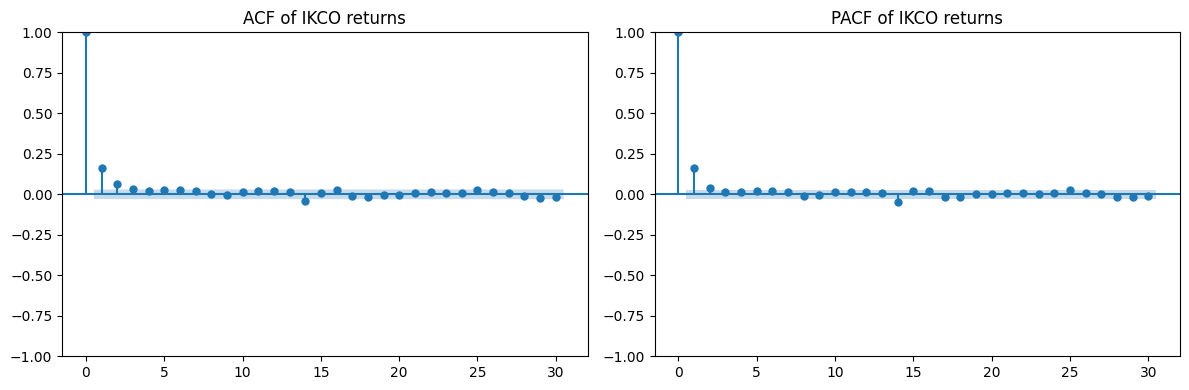

In [5]:
series = df["ret"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(series, lags=30, ax=axes[0])
axes[0].set_title("ACF of IKCO returns")
plot_pacf(series, lags=30, ax=axes[1])
axes[1].set_title("PACF of IKCO returns")
plt.tight_layout()
plt.show()


In [6]:
# AR(1) on returns
model_ar1 = ARIMA(series, order=(1, 0, 0))
res_ar1 = model_ar1.fit()

print(res_ar1.summary())


c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                 4568
Model:                 ARIMA(1, 0, 0)   Log Likelihood                9599.794
Date:                Fri, 27 Feb 2026   AIC                         -19193.588
Time:                        23:13:53   BIC                         -19174.308
Sample:                             0   HQIC                        -19186.800
                               - 4568                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.001      1.173      0.241      -0.000       0.002
ar.L1          0.1649      0.005     36.346      0.000       0.156       0.174
sigma2         0.0009   2.01e-06    436.299      0.0

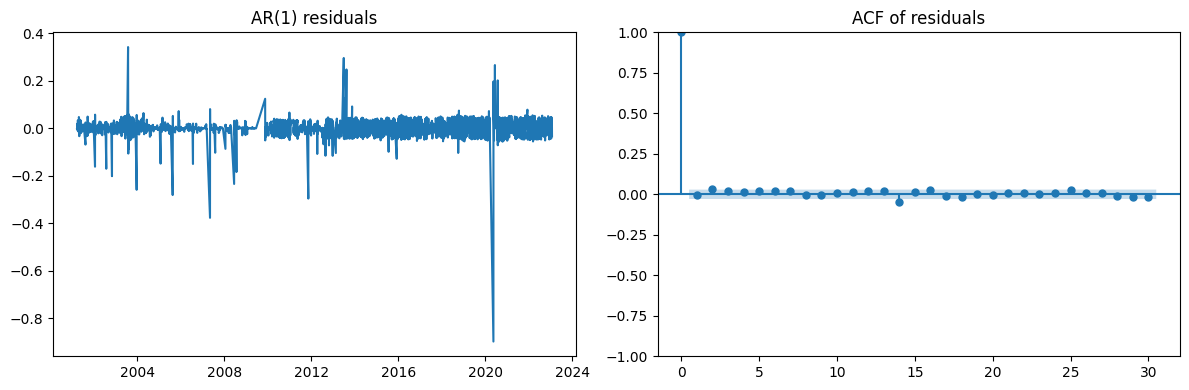

In [7]:
residuals = res_ar1.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(residuals)
axes[0].set_title("AR(1) residuals")

plot_acf(residuals, lags=30, ax=axes[1])
axes[1].set_title("ACF of residuals")
plt.tight_layout()
plt.show()


In [8]:
# AR(2) model
model_ar2 = ARIMA(series, order=(2, 0, 0))
res_ar2 = model_ar2.fit()

print(res_ar2.summary())


c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                 4568
Model:                 ARIMA(2, 0, 0)   Log Likelihood                9602.948
Date:                Fri, 27 Feb 2026   AIC                         -19197.896
Time:                        23:14:56   BIC                         -19172.189
Sample:                             0   HQIC                        -19188.845
                               - 4568                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.001      1.124      0.261      -0.001       0.002
ar.L1          0.1588      0.005     34.086      0.000       0.150       0.168
ar.L2          0.0372      0.010      3.702      0.0

In [9]:
# MA(1) model
model_ma1 = ARIMA(series, order=(0, 0, 1))
res_ma1 = model_ma1.fit()

print(res_ma1.summary())


c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                 4568
Model:                 ARIMA(0, 0, 1)   Log Likelihood                9594.241
Date:                Fri, 27 Feb 2026   AIC                         -19182.483
Time:                        23:15:01   BIC                         -19163.202
Sample:                             0   HQIC                        -19175.694
                               - 4568                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.001      1.207      0.227      -0.000       0.002
ma.L1          0.1582      0.005     33.625      0.000       0.149       0.167
sigma2         0.0009   2.02e-06    435.257      0.0

In [10]:
# ARMA(1,1) model
model_arma11 = ARIMA(series, order=(1, 0, 1))
res_arma11 = model_arma11.fit()

print(res_arma11.summary())


c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                 4568
Model:                 ARIMA(1, 0, 1)   Log Likelihood                9603.603
Date:                Fri, 27 Feb 2026   AIC                         -19199.205
Time:                        23:15:06   BIC                         -19173.498
Sample:                             0   HQIC                        -19190.154
                               - 4568                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.001      1.103      0.270      -0.001       0.002
ar.L1          0.3937      0.055      7.169      0.000       0.286       0.501
ma.L1         -0.2354      0.056     -4.219      0.0

<Figure size 1000x400 with 0 Axes>

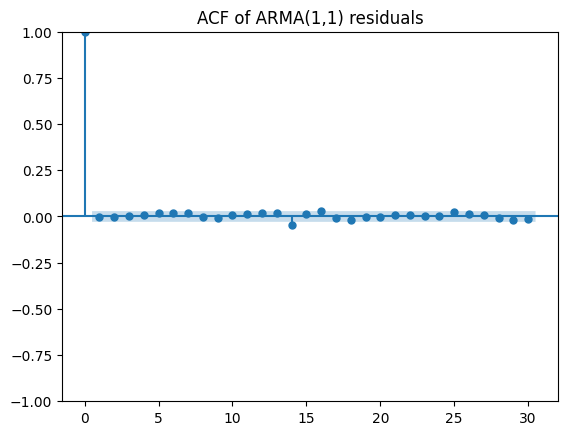

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

resid_arma = res_arma11.resid

plt.figure(figsize=(10,4))
plot_acf(resid_arma, lags=30)
plt.title("ACF of ARMA(1,1) residuals")
plt.show()


In [12]:
price = df["close"]

# first difference
price_diff = price.diff().dropna()

# e.g. ARIMA(1,1,1) روی قیمت خام:
model_arima = ARIMA(price, order=(1, 1, 1))
res_arima = model_arima.fit()

print(res_arima.summary())


c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 4568
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -30378.189
Date:                Fri, 27 Feb 2026   AIC                          60762.377
Time:                        23:15:19   BIC                          60781.657
Sample:                             0   HQIC                         60769.166
                               - 4568                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4993      0.098      5.071      0.000       0.306       0.692
ma.L1         -0.4336      0.100     -4.345      0.000      -0.629      -0.238
sigma2      3.517e+04     24.676   1425.319      0.0

In [13]:
series = df["ret"]   # cleaned returns

from statsmodels.tsa.arima.model import ARIMA

model_ar1 = ARIMA(series, order=(1, 0, 0))
res_ar1 = model_ar1.fit()

print(res_ar1.summary())


c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                 4568
Model:                 ARIMA(1, 0, 0)   Log Likelihood                9599.794
Date:                Fri, 27 Feb 2026   AIC                         -19193.588
Time:                        23:15:41   BIC                         -19174.308
Sample:                             0   HQIC                        -19186.800
                               - 4568                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.001      1.173      0.241      -0.000       0.002
ar.L1          0.1649      0.005     36.346      0.000       0.156       0.174
sigma2         0.0009   2.01e-06    436.299      0.0

<Figure size 1000x400 with 0 Axes>

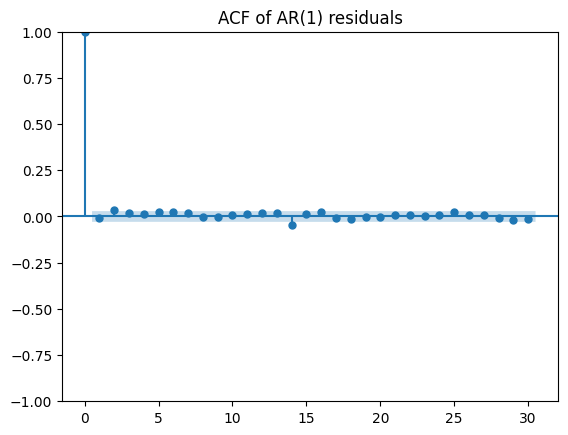

In [14]:
resid_ar1 = res_ar1.resid

from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plot_acf(resid_ar1, lags=30)
plt.title("ACF of AR(1) residuals")
plt.show()


In [15]:
model_ar2 = ARIMA(series, order=(2, 0, 0))
res_ar2 = model_ar2.fit()

print(res_ar2.summary())


c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                 4568
Model:                 ARIMA(2, 0, 0)   Log Likelihood                9602.948
Date:                Fri, 27 Feb 2026   AIC                         -19197.896
Time:                        23:15:52   BIC                         -19172.189
Sample:                             0   HQIC                        -19188.845
                               - 4568                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.001      1.124      0.261      -0.001       0.002
ar.L1          0.1588      0.005     34.086      0.000       0.150       0.168
ar.L2          0.0372      0.010      3.702      0.0

In [16]:
model_arma11 = ARIMA(series, order=(1, 0, 1))
res_arma11 = model_arma11.fit()

print(res_arma11.summary())


c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Desktop\IKCO_preprocessing\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                 4568
Model:                 ARIMA(1, 0, 1)   Log Likelihood                9603.603
Date:                Fri, 27 Feb 2026   AIC                         -19199.205
Time:                        23:15:56   BIC                         -19173.498
Sample:                             0   HQIC                        -19190.154
                               - 4568                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.001      1.103      0.270      -0.001       0.002
ar.L1          0.3937      0.055      7.169      0.000       0.286       0.501
ma.L1         -0.2354      0.056     -4.219      0.0

<Figure size 1000x400 with 0 Axes>

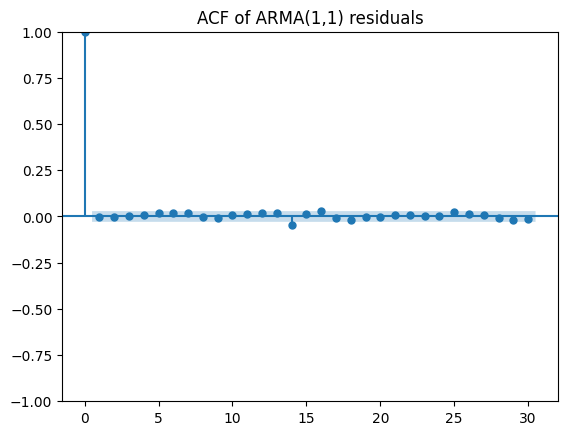

In [17]:
resid_arma = res_arma11.resid

plt.figure(figsize=(10,4))
plot_acf(resid_arma, lags=30)
plt.title("ACF of ARMA(1,1) residuals")
plt.show()
